In [1]:
!sudo apt update 
!sudo apt-get install python3-opencv -y
!pip install opencv-python

Get:1 https://packages.microsoft.com/repos/microsoft-ubuntu-focal-prod focal InRelease [3632 B]
Get:2 http://archive.ubuntu.com/ubuntu focal InRelease [265 kB]                
Get:3 https://dl.yarnpkg.com/debian stable InRelease [17.1 kB]                 
Get:4 http://archive.ubuntu.com/ubuntu focal-updates InRelease [128 kB]        
Get:5 http://archive.ubuntu.com/ubuntu focal-backports InRelease [128 kB]      
Get:6 http://security.ubuntu.com/ubuntu focal-security InRelease [128 kB]      
Get:7 https://repo.anaconda.com/pkgs/misc/debrepo/conda stable InRelease [3961 B]0m
Get:8 https://packages.microsoft.com/repos/microsoft-ubuntu-focal-prod focal/main amd64 Packages [311 kB]
Get:9 https://packages.microsoft.com/repos/microsoft-ubuntu-focal-prod focal/main all Packages [2714 B]
Get:11 https://dl.yarnpkg.com/debian stable/main all Packages [11.8 kB]
Get:12 https://dl.yarnpkg.com/debian stable/main amd64 Packages [11.8 kB]m
Get:10 https://packagecloud.io/github/git-lfs/ubuntu focal InRe

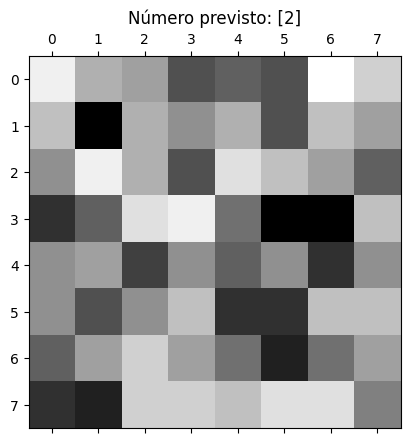

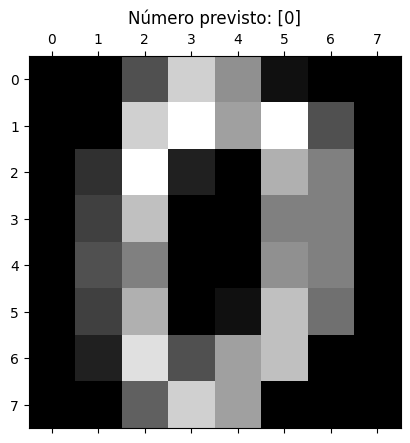

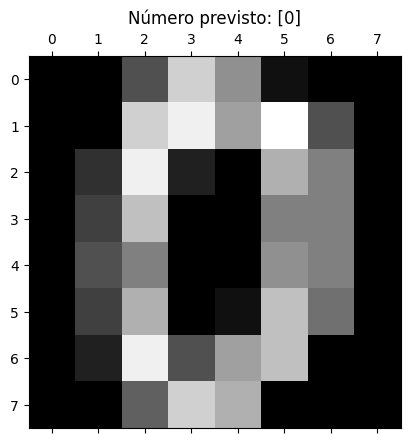

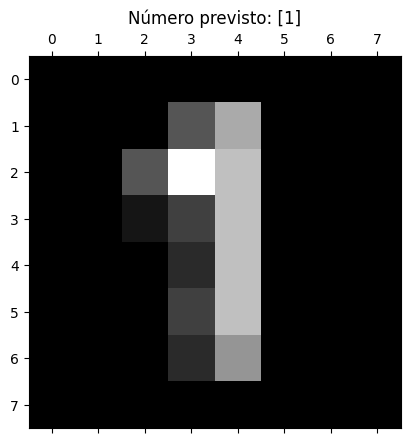

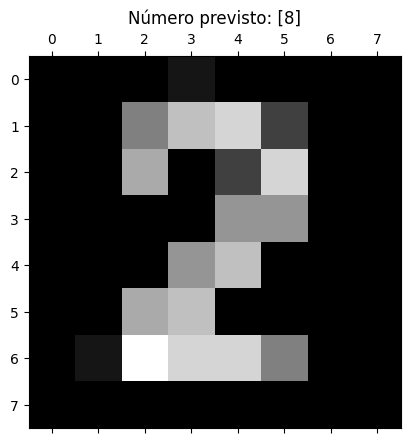

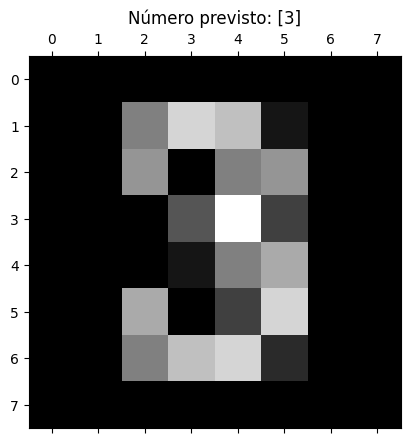

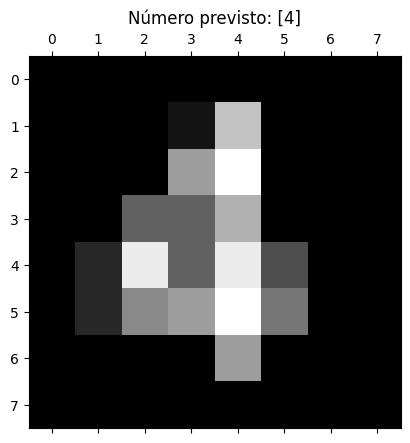

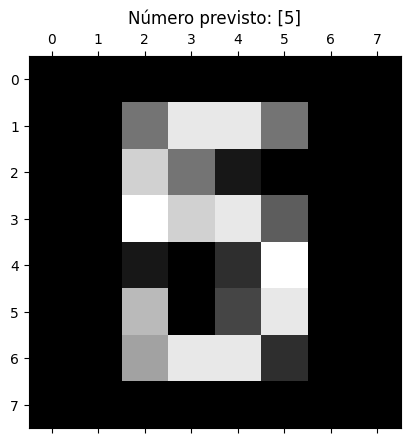

In [2]:
import cv2
import numpy as np
import requests
import os
import warnings
import matplotlib.pyplot as plt

warnings.simplefilter(action='ignore', category=DeprecationWarning)	

url = 'http://127.0.0.1:8000/predict/'

arquivos = ['../imagens/imagem_negativa.png', 
            '../imagens/imagem_positiva.png', 
            '../imagens/imagem_positiva_ruido.png',
            '../imagens/1.png',
            '../imagens/2.png',
            '../imagens/3.png',
            '../imagens/4.png',
            '../imagens/5.png',]

for arquivo in arquivos:
    if not os.path.isfile(arquivo):
        print(f"{arquivo} -> Arquivo não encontrado")
    else:
        #Le o arquivo com a imagem a ser processada
        image = cv2.imread(arquivo)

        # Prepara a imagem para envio na requisicao da API
        # Converte para escala de cinza
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Escala o valor dos pixels de  0-255 apra 0-16
        scaled_image = (gray_image / 255.0 * 16).astype(np.uint8)
        # Converte para lista 
        scaled_image_list = scaled_image.reshape(1, -1).tolist()
        # Monta o dicionario para envio
        data = {
            'image': scaled_image_list
        }

        try:
            response = requests.post(url, json=data)
            if response.status_code == 200:
                # se deu certo, exibe a imagem com a previsão no título
                result = response.json()
                plt.matshow(scaled_image.reshape((8, 8)))
                plt.title(f"Número previsto: {result['predict']}") 
                plt.gray()
                plt.show()
            else:
                #se a resposta não foi OK exibe o status code
                print(response.status_code)
        except requests.exceptions.HTTPError as http_err:
            print(f"{arquivo} -> erro de HTTP: {http_err}")
        except requests.exceptions.ConnectionError as conn_err:
            print(f"{arquivo} -> erro de conexão: {conn_err}")
        except requests.exceptions.Timeout as timeout_err:
            print(f"{arquivo} -> erro de Timeout: {timeout_err}")
        except requests.exceptions.RequestException as req_err:
            print(f"{arquivo} -> erro: {req_err}")

